In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import warnings
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Этап 1. Исследование и анализ датасета (EDA);**

In [7]:
dataset = pd.read_csv('/content/drive/MyDrive/Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)

In [10]:
dataset

,0,1,2,3,4,5,6,7,8,9,...,495,496,497,498,499,500,501,502,503,504
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,...,14822,14815,14815,14817,14819,14820,14822,14820,14819,NaN
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,...,14817,14824,14822,14824,14819,14820,14819,14822,14820,NaN
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824,...,14821,14820,14820,14818,14821,14823,14820,14820,14821,NaN
3,15798632,841,123,500,14828,14822,14818,14824,14824,14822,...,14826,14822,14821,14820,14828,14820,14822,14823,14822,NaN
4,20637296,412,348,500,14823,14815,14823,14821,14827,14820,...,14820,14823,14828,14824,14820,14824,14824,14822,14825,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23474,199983883854,794,100,500,14826,14827,14825,14818,14825,14827,...,14828,14825,14819,14826,14828,14822,14824,14824,14827,NaN
23475,199992116348,833,1252,500,14824,14823,14819,14828,14819,14824,...,14826,14824,14814,14814,14818,14816,14822,14819,14817,NaN
23476,199993451438,716,1055,500,14822,14822,14824,14820,14823,14828,...,14817,14815,14817,14818,14817,14816,14819,14817,14820,NaN
23477,199999096118,505,323,500,14824,14823,14824,14822,14821,14824,...,14824,14827,14822,14825,14824,14822,14820,14819,14824,NaN


In [11]:
dataset = dataset.drop([0, 1, 2, 3, 504], axis=1)

In [13]:
dataset.columns = list(range(500))

In [14]:
 dataset.shape

(23479, 500)

In [15]:
dataset.isnull().sum().sum()

np.int64(0)

In [16]:
dataset.describe()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
count,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,...,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000
mean,14822.972316,14822.958474,14822.970016,14822.989991,14823.003961,14822.978619,14822.968610,14822.954470,14822.963670,14822.968908,...,14822.329017,14822.315686,14822.272073,14822.171728,14822.257123,14822.317092,14822.279399,14822.278163,14822.287789,14822.283743
std,2.805884,2.833516,2.840755,2.852066,2.833412,2.836271,2.831241,2.827526,2.846291,2.814655,...,3.357997,3.373568,3.340707,3.332547,3.290301,3.232245,3.268458,3.251192,3.253340,3.242307
min,14812.000000,14812.000000,14812.000000,14811.000000,14812.000000,14812.000000,14812.000000,14811.000000,14812.000000,14809.000000,...,14800.000000,14798.000000,14802.000000,14796.000000,14802.000000,14801.000000,14798.000000,14804.000000,14800.000000,14802.000000
25%,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,...,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000
50%,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,...,14823.000000,14823.000000,14823.000000,14822.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000
75%,14824.000000,14824.000000,14825.000000,14825.000000,14825.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,...,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000
max,14834.000000,14835.000000,14834.000000,14835.000000,14834.000000,14835.000000,14835.000000,14833.000000,14834.000000,14834.000000,...,14836.000000,14835.000000,14834.000000,14836.000000,14833.000000,14834.000000,14833.000000,14834.000000,14833.000000,14835.000000


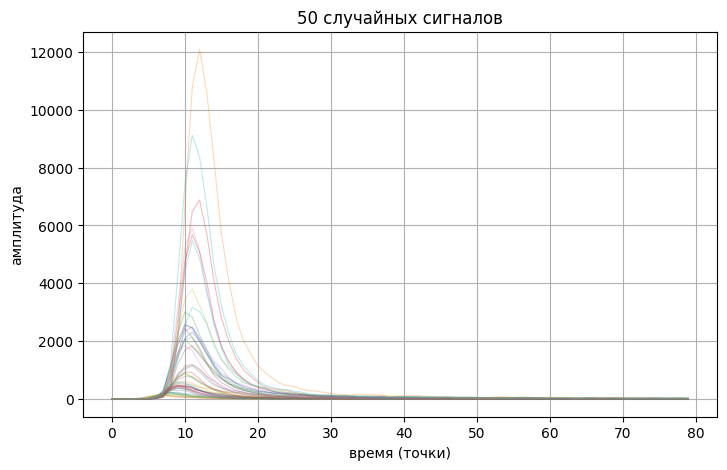

In [18]:
signals = (2**14 - dataset - 1560).values
signals_active = signals[:, 140:220]
np.random.seed(42)
idx = np.random.choice(len(signals), 50, replace=False)

plt.figure(figsize=(18, 5))
plt.subplot(1, 2, 1)
for i in idx[:50]:
    plt.plot(signals[i, 140:220], alpha=0.3, linewidth=0.8)
plt.title('50 случайных сигналов')
plt.xlabel('время (точки)')
plt.ylabel('амплитуда')
plt.grid(True)

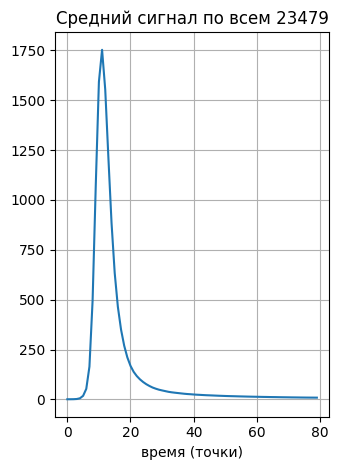

In [19]:
plt.subplot(1, 2, 2)
plt.plot(signals[:, 140:220].mean(axis=0))
plt.title('Средний сигнал по всем 23479')
plt.xlabel('время (точки)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
# находим пик каждого сигнала
peak_positions = np.argmax(signals_active, axis=1)
peak_amplitudes = signals_active.max(axis=1)

In [21]:
print("позиция (среднее):", peak_positions.mean().round(1))
print("амплитуда мин/макс:", peak_amplitudes.min(), peak_amplitudes.max())
print("сигналы с почти нулевой амплитудой (< 10):", (peak_amplitudes < 10).sum())

позиция (среднее): 9.6
амплитуда мин/макс: 105 14824
сигналы с почти нулевой амплитудой (< 10): 0


Все сигналы имеют пик около точки 9-10, хвост разной длины. Амплитуда от 105 до 14824 разброс огромный. Аномальных по амплитуде нет совсем.

In [23]:
def extract_features(signals):
    feats = {}

    S = signals[:, 140:220]
    peak_amp = S.max(axis=1)
    peak_pos = S.argmax(axis=1)

    feats['peak_amplitude'] = peak_amp
    feats['peak_position'] = peak_pos

    total_charge = S.sum(axis=1)
    feats['total_charge'] = total_charge

    tail_charge = np.array([
        S[i, peak_pos[i]+3:].sum() for i in range(len(S))
    ])
    feats['tail_charge'] = tail_charge

    # PSD
    feats['psd_ratio'] = tail_charge / (total_charge + 1e-9)

    half_max = peak_amp / 2
    feats['peak_width'] = (S > half_max[:, None]).sum(axis=1)

    feats['rise_time'] = peak_pos

    decay_time = []
    for i in range(len(S)):
        after_peak = S[i, peak_pos[i]:]
        idx = np.where(after_peak < 0.1 * peak_amp[i])[0]
        decay_time.append(idx[0] if len(idx) > 0 else 80)
    feats['decay_time'] = np.array(decay_time)

    feats['baseline_std'] = S[:, :5].std(axis=1)

    return pd.DataFrame(feats)

features = extract_features(signals)
print(features.shape)
print(features.describe())

(23479, 9)
       peak_amplitude  peak_position   total_charge   tail_charge  \
count    23479.000000   23479.000000   23479.000000  23479.000000   
mean      1836.123259       9.614847   12583.827505   4883.571362   
std       2389.316432       1.331726   15505.149915   5644.666526   
min        105.000000       5.000000     597.000000    143.000000   
25%        309.000000       9.000000    2365.500000   1035.000000   
50%        814.000000      10.000000    5924.000000   2528.000000   
75%       2316.000000      11.000000   16329.000000   6649.000000   
max      14824.000000      12.000000  110459.000000  49639.000000   

          psd_ratio    peak_width     rise_time    decay_time  baseline_std  
count  23479.000000  23479.000000  23479.000000  23479.000000  23479.000000  
mean       0.418975      5.228161      9.614847     10.259934      3.410017  
std        0.081812      0.700381      1.331726      2.263563      3.204480  
min        0.170644      3.000000      5.000000      4.

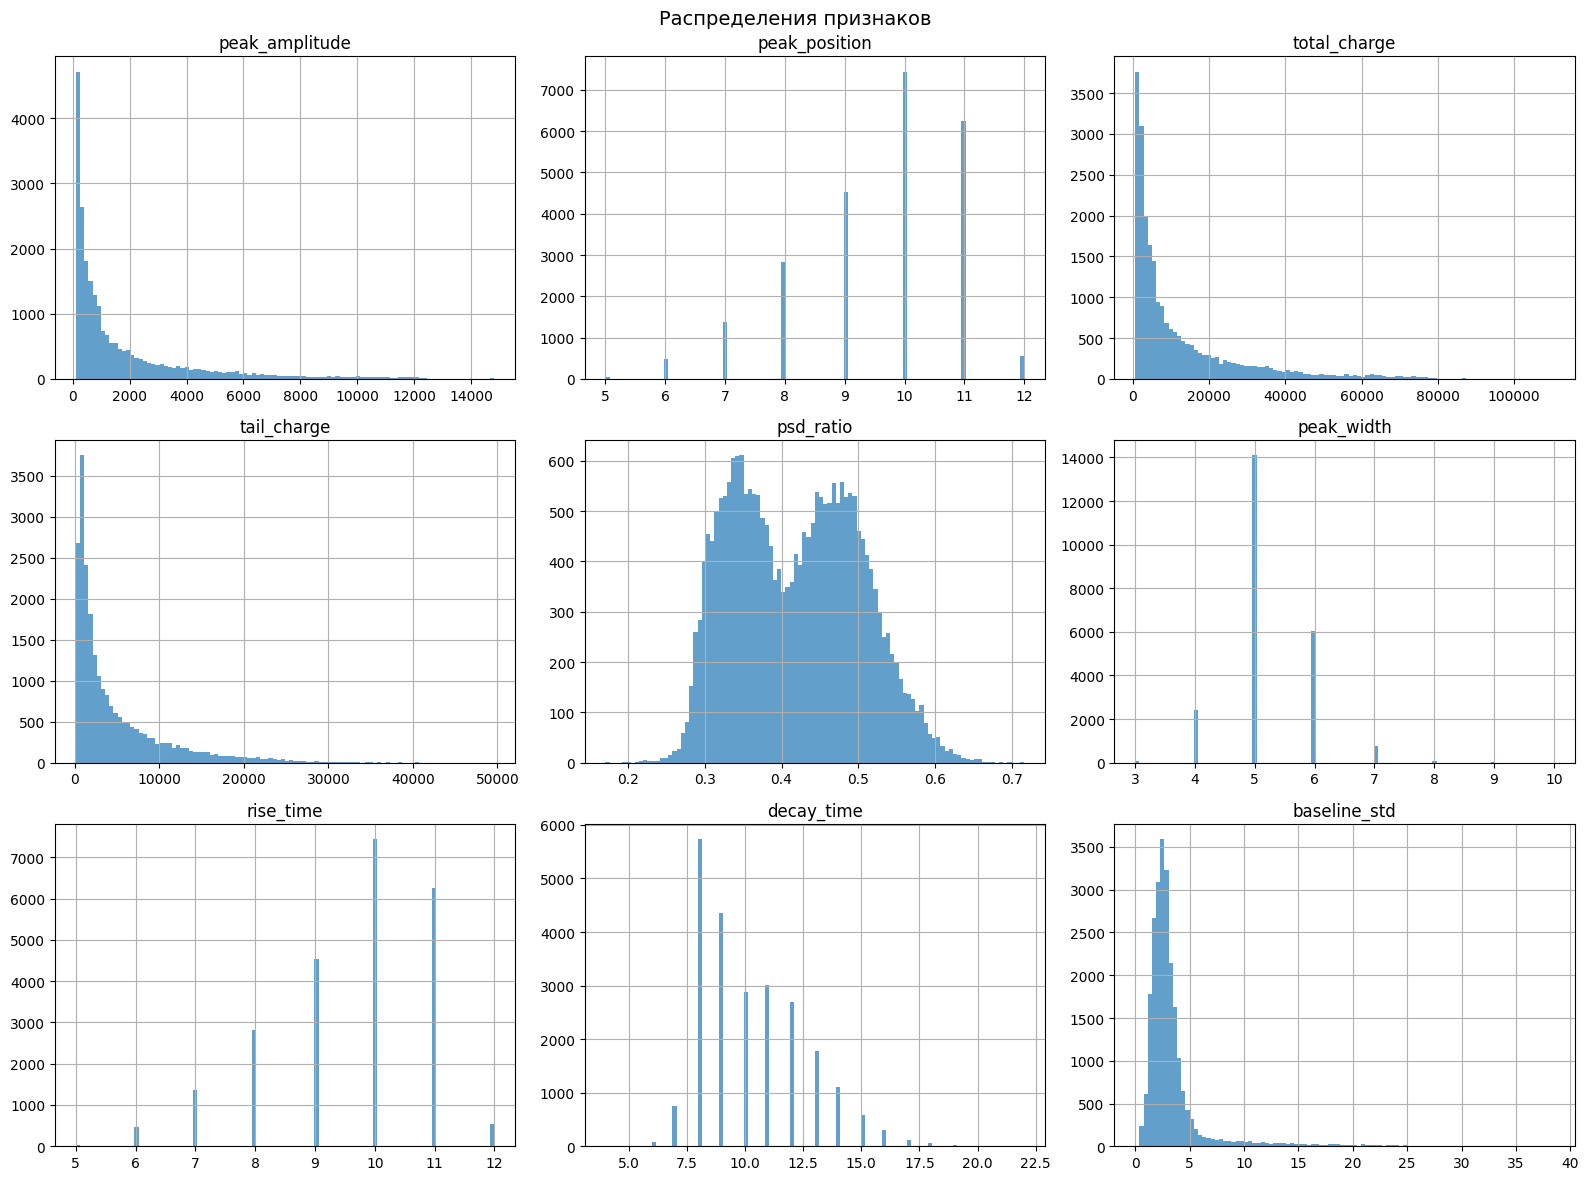

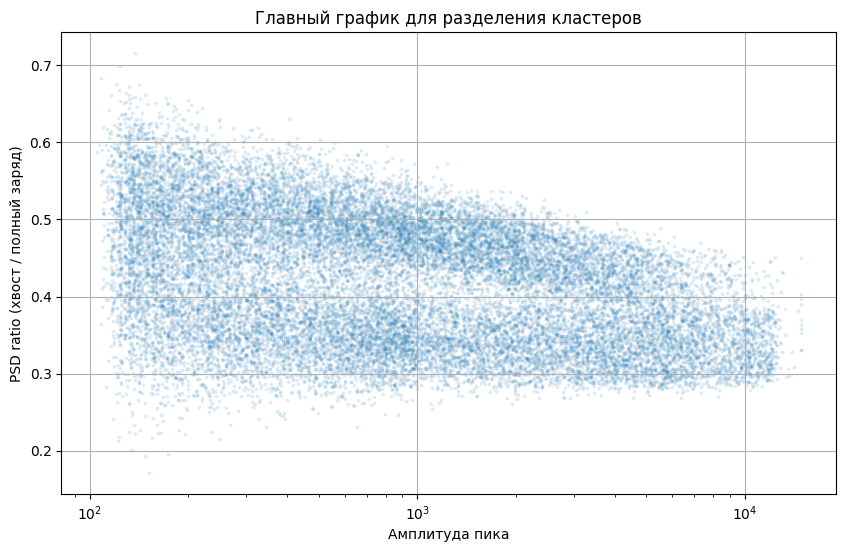

In [24]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features.columns):
    axes[i].hist(features[col], bins=100, edgecolor='none', alpha=0.7)
    axes[i].set_title(col)
    axes[i].grid(True)

plt.suptitle('Распределения признаков', fontsize=14)
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 6))
plt.scatter(features['peak_amplitude'], features['psd_ratio'],
            alpha=0.1, s=3)
plt.xlabel('Амплитуда пика')
plt.ylabel('PSD ratio (хвост / полный заряд)')
plt.title('Главный график для разделения кластеров')
plt.xscale('log')
plt.grid(True)
plt.show()

Датасет содержит 23 479 сигналов по 500 точек каждый, пропусков нет.
После инверсии сигналов активная часть находится в диапазоне точек 140-220.

Амплитуда сигналов разбросана от 105 до 14 824, большинство сигналов слабые, распределение сильно скошено. Это говорит о том что энергий частиц много разных.

Самый важный результат это распределение PSD ratio показывает два чётких
горба около 0.33 и 0.50. Это прямое свидетельство двух типов частиц гамма-кванты имеют короткий хвост (низкий PSD), нейтроны длинный хвост (высокий PSD).

При малых амплитудах два горба сильно перекрываются это
 она где сигналы сложно отнести к одному из типов. Такие сигналы скорее
всего и составят третий кластер аномальных.

**ЭТАП 2. Предобработка данных**

In [26]:
#Извлекаем все признаки
S = signals[:, 140:220]
peak_amp = S.max(axis=1)
peak_pos = S.argmax(axis=1)
total_charge = S.sum(axis=1)
tail_charge = np.array([S[i, peak_pos[i]+3:].sum() for i in range(len(S))])
psd_ratio = tail_charge / (total_charge + 1e-9)
half_max = peak_amp / 2
peak_width = (S > half_max[:, None]).sum(axis=1)
baseline_std = S[:, :5].std(axis=1)
decay_time = []
for i in range(len(S)):
    after_peak = S[i, peak_pos[i]:]
    idx = np.where(after_peak < 0.1 * peak_amp[i])[0]
    decay_time.append(idx[0] if len(idx) > 0 else 80)
decay_time = np.array(decay_time)

features = pd.DataFrame({
    'peak_amplitude': peak_amp,
    'total_charge':   total_charge,
    'tail_charge':    tail_charge,
    'psd_ratio':      psd_ratio,
    'peak_width':     peak_width,
    'decay_time':     decay_time,
    'baseline_std':   baseline_std,
})

In [27]:
print("Выбросы baseline_std > 10:", (features['baseline_std'] > 10).sum())
print("Выбросы peak_amplitude > 14000:", (features['peak_amplitude'] > 14000).sum())

Выбросы baseline_std > 10: 996
Выбросы peak_amplitude > 14000: 12


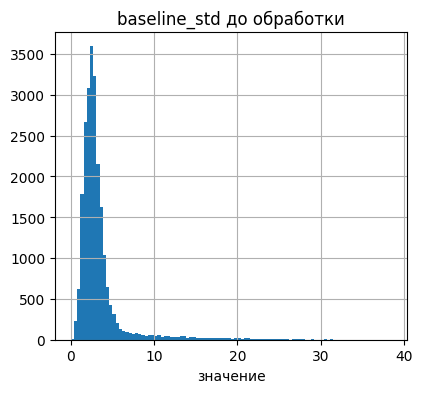

In [28]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(features['baseline_std'], bins=100)
plt.title('baseline_std до обработки')
plt.xlabel('значение')
plt.grid(True)

In [29]:
p99 = features['baseline_std'].quantile(0.99)
features['baseline_std'] = features['baseline_std'].clip(upper=p99)

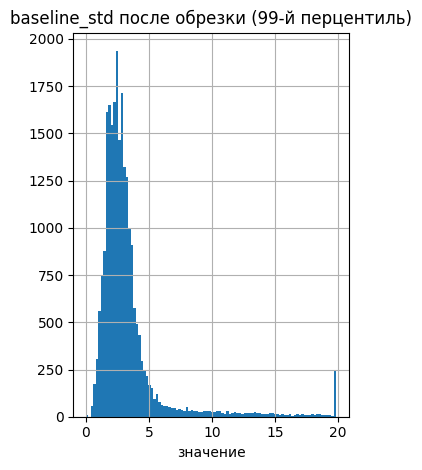

In [30]:
plt.subplot(1, 2, 2)
plt.hist(features['baseline_std'], bins=100)
plt.title('baseline_std после обрезки (99-й перцентиль)')
plt.xlabel('значение')
plt.grid(True)
plt.tight_layout()
plt.show()

In [31]:
features['peak_amplitude_log'] = np.log1p(features['peak_amplitude'])
features['total_charge_log']   = np.log1p(features['total_charge'])
features['tail_charge_log']    = np.log1p(features['tail_charge'])

In [32]:
# Итоговый набор признаков для кластеризации
feature_cols = [
    'psd_ratio',
    'peak_amplitude_log',
    'total_charge_log',
    'tail_charge_log',
    'peak_width',
    'decay_time',
    'baseline_std',
]


После масштабирования — средние (должны быть ~0):
psd_ratio             0.0
peak_amplitude_log    0.0
total_charge_log     -0.0
tail_charge_log      -0.0
peak_width            0.0
decay_time            0.0
baseline_std         -0.0
dtype: float64

После масштабирования — стандартные отклонения (должны быть ~1):
psd_ratio             1.0
peak_amplitude_log    1.0
total_charge_log      1.0
tail_charge_log       1.0
peak_width            1.0
decay_time            1.0
baseline_std          1.0
dtype: float64


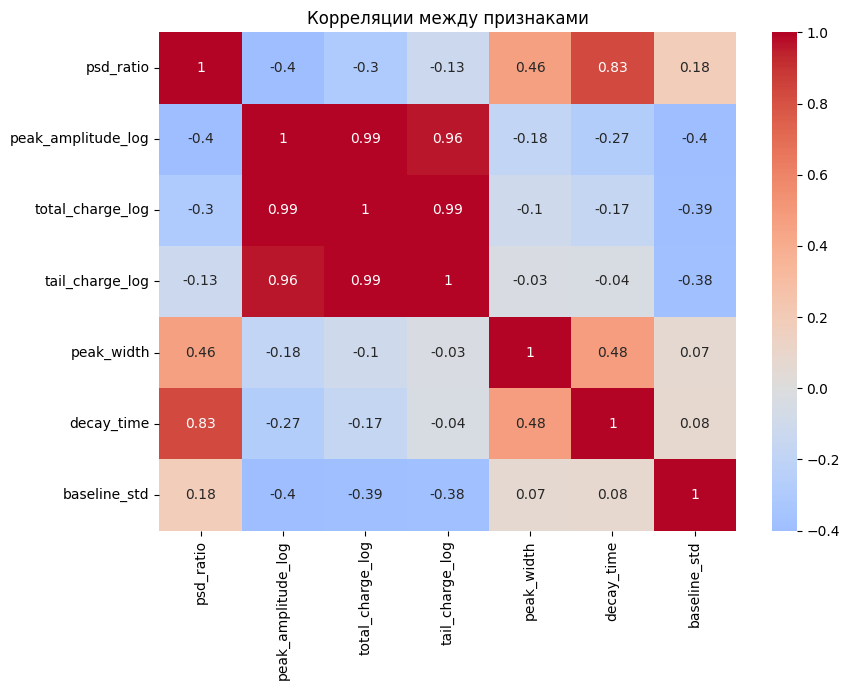

In [33]:
X = features[feature_cols].copy()

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print("\nПосле масштабирования — средние (должны быть ~0):")
print(X_scaled.mean().round(3))
print("\nПосле масштабирования — стандартные отклонения (должны быть ~1):")
print(X_scaled.std().round(3))

# Матрица корреляций
plt.figure(figsize=(9, 7))
sns.heatmap(features[feature_cols].corr().round(2),
            annot=True, cmap='coolwarm', center=0)
plt.title('Корреляции между признаками')
plt.tight_layout()
plt.show()

**вывод**

Из 500 точек каждого сигнала оставили только активную зону 140-220,
где находится весь полезный сигнал. Остальные 420 точек это шум базовой линии
и они не несут полезной информации.

996 сигналов имели сильно зашумлённую базовую линию (baseline_std > 10).
Обрезали значения на уровне 99 перцентиля чтобы эти выбросы
не тянули кластеры в сторону.

Амплитуда и заряды распределены экспоненциально, поэтому применили
логарифмирование — это выравнивает распределение и помогает
алгоритмам кластеризации работать корректно.

Из матрицы корреляций видно что peak_amplitude_log, total_charge_log
и tail_charge_log очень сильно коррелируют между собой (0.96-0.99).
Это означает что они несут почти одинаковую информацию. На следующем
этапе уберём лишние из них.

Самый важный признак psd_ratio сильно коррелирует с decay_time (0.83)
что логично — чем длиннее хвост сигнала, тем дольше он спадает.
После масштабирования все признаки приведены к среднему 0
и стандартному отклонению 1.

**ЭТАП 3. Feature Engineering**

In [34]:
# Добавляем новый признак, нормированный хвост относительно амплитуды
features['tail_to_peak'] = features['tail_charge'] / (features['peak_amplitude'] + 1e-9)
features['tail_to_peak_log'] = np.log1p(features['tail_to_peak'])


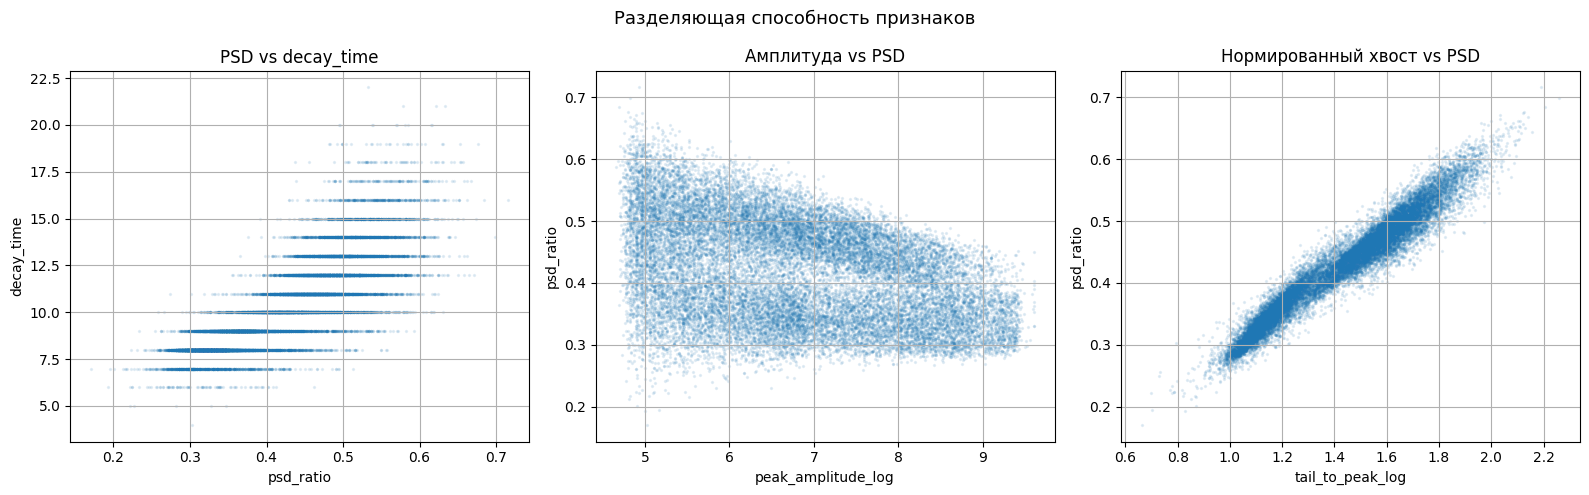

Итоговое число признаков: 6
Признаки: ['psd_ratio', 'peak_amplitude_log', 'decay_time', 'peak_width', 'tail_to_peak_log', 'baseline_std']


In [35]:
# Итоговый набор
feature_cols_final = [
    'psd_ratio',           # главный физический признак
    'peak_amplitude_log',  # энергия сигнала
    'decay_time',          # время спада
    'peak_width',          # ширина пика
    'tail_to_peak_log',    # нормированный хвост
    'baseline_std',        # качество сигнала
]

X_final = features[feature_cols_final].copy()

scaler2 = StandardScaler()
X_final_scaled = scaler2.fit_transform(X_final)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(features['psd_ratio'], features['decay_time'],
                alpha=0.1, s=2)
axes[0].set_xlabel('psd_ratio')
axes[0].set_ylabel('decay_time')
axes[0].set_title('PSD vs decay_time')
axes[0].grid(True)

axes[1].scatter(features['peak_amplitude_log'], features['psd_ratio'],
                alpha=0.1, s=2)
axes[1].set_xlabel('peak_amplitude_log')
axes[1].set_ylabel('psd_ratio')
axes[1].set_title('Амплитуда vs PSD')
axes[1].grid(True)

axes[2].scatter(features['tail_to_peak_log'], features['psd_ratio'],
                alpha=0.1, s=2)
axes[2].set_xlabel('tail_to_peak_log')
axes[2].set_ylabel('psd_ratio')
axes[2].set_title('Нормированный хвост vs PSD')
axes[2].grid(True)

plt.suptitle('Разделяющая способность признаков', fontsize=13)
plt.tight_layout()
plt.show()

print("Итоговое число признаков:", len(feature_cols_final))
print("Признаки:", feature_cols_final)

**вывод**

Убрали два сильно коррелирующих признака total_charge_log и tail_charge_log
так как они почти дублируют peak_amplitude_log. Оставить все три значило бы
давать амплитуде тройной вес при кластеризации.

Добавили новый признак tail_to_peak_log это отношение заряда хвоста к амплитуде пика.
На третьем графике видно что он практически линейно связан с psd_ratio,
то есть оба признака описывают одно и то же физическое явление, это хорошее подтверждение что признаки извлечены правильно.

На первом графике decay_time принимает дискретные значения, особенность
того как считается время спада по порогу. Признак всё равно полезен так как
разделяет сигналы по горизонтали.

Итого оставили 6 признаков которые описывают сигнал с разных сторон:
форму хвоста (psd_ratio, tail_to_peak_log), энергию (peak_amplitude_log),
время спада (decay_time), ширину пика (peak_width) и качество записи (baseline_std).

**ЭТАП 4. Подбор признаков, их анализ и оценка важности**

Объяснённая дисперсия по компонентам: [0.561 0.202]
Суммарно: 0.764


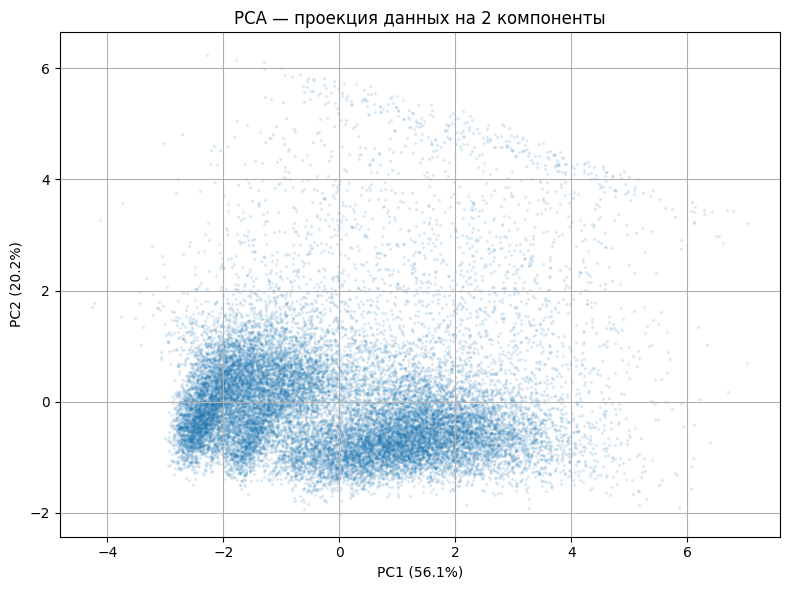

In [37]:
# Смотрим как признаки разделяют данные через PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_final_scaled)

print("Объяснённая дисперсия по компонентам:", pca.explained_variance_ratio_.round(3))
print("Суммарно:", pca.explained_variance_ratio_.sum().round(3))

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.1, s=2)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA — проекция данных на 2 компоненты')
plt.grid(True)
plt.tight_layout()
plt.show()


In [38]:
# Вклад каждого признака в главные компоненты
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols_final,
    columns=['PC1', 'PC2']
).round(3)
print("\nВклад признаков в компоненты PCA:")
print(loadings)




Вклад признаков в компоненты PCA:
                      PC1    PC2
psd_ratio           0.513 -0.087
peak_amplitude_log -0.284 -0.573
decay_time          0.481 -0.223
peak_width          0.347 -0.218
tail_to_peak_log    0.529 -0.101
baseline_std        0.157  0.746


In [39]:
print("\nСтандартное отклонение признаков (до масштабирования):")
print(features[feature_cols_final].std().round(3).sort_values(ascending=False))




Стандартное отклонение признаков (до масштабирования):
baseline_std          2.950
decay_time            2.264
peak_amplitude_log    1.231
peak_width            0.700
tail_to_peak_log      0.258
psd_ratio             0.082
dtype: float64


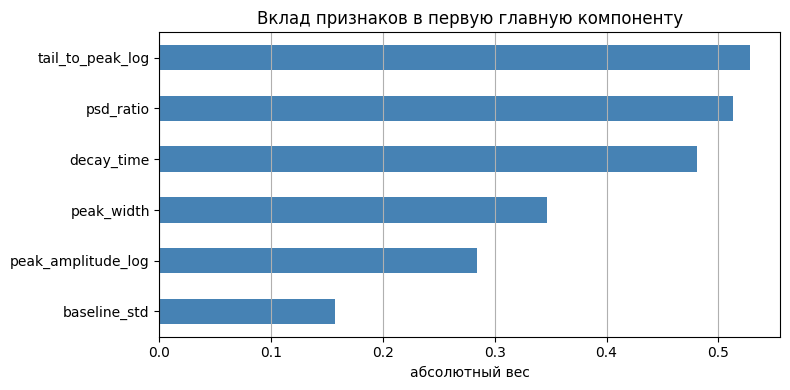

In [40]:
var_importance = np.abs(pca.components_[0])
feat_importance = pd.Series(var_importance, index=feature_cols_final).sort_values()

plt.figure(figsize=(8, 4))
feat_importance.plot(kind='barh', color='steelblue')
plt.title('Вклад признаков в первую главную компоненту')
plt.xlabel('абсолютный вес')
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

**вывод**

PCA показал что две главные компоненты объясняют 76.4% дисперсии данных
(56.1% + 20.2%). На графике PCA видны две плотные группы точек и облако
рассеянных точек сверху.

Первая компонента PC1 отвечает за форму хвоста сигнала и наибольший вклад
вносят tail_to_peak_log (0.53), psd_ratio (0.51) и decay_time (0.48)
Именно по этой оси разделяются гамма кванты и нейтроны.

Вторая компонента PC2 в основном определяется baseline_std (0.75),
она отделяет зашумлённые сигналы от чистых. Это и есть третий кластер
аномальных сигналов.

Признак baseline_std наименее важен для разделения типов частиц,
но важен для выявления аномалий.

**ЭТАП 5. Обучение нескольких моделей и их сравнение**

In [43]:
results = []

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
labels_km = kmeans.fit_predict(X_final_scaled)

sil_km = silhouette_score(X_final_scaled, labels_km, sample_size=5000, random_state=42)
ch_km  = calinski_harabasz_score(X_final_scaled, labels_km)
db_km  = davies_bouldin_score(X_final_scaled, labels_km)
results.append({'Модель': 'KMeans', 'Силуэт': sil_km, 'Calinski-Harabasz': ch_km, 'Davies-Bouldin': db_km})
print("KMeans готов, кластеры:", np.bincount(labels_km))

KMeans готов, кластеры: [ 1212 10107 12160]


In [44]:
#GaussianMixture
gmm = GaussianMixture(n_components=3, random_state=42, n_init=5)
labels_gmm = gmm.fit_predict(X_final_scaled)

sil_gmm = silhouette_score(X_final_scaled, labels_gmm, sample_size=5000, random_state=42)
ch_gmm  = calinski_harabasz_score(X_final_scaled, labels_gmm)
db_gmm  = davies_bouldin_score(X_final_scaled, labels_gmm)
results.append({'Модель': 'GaussianMixture', 'Силуэт': sil_gmm, 'Calinski-Harabasz': ch_gmm, 'Davies-Bouldin': db_gmm})
print("GMM готов, кластеры:", np.bincount(labels_gmm))


GMM готов, кластеры: [4200 9603 9676]


In [45]:
# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=10, n_jobs=-1)
labels_db = dbscan.fit_predict(X_final_scaled)
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db = (labels_db == -1).sum()
print(f"DBSCAN готов, кластеров: {n_clusters_db}, шум: {n_noise_db}")

DBSCAN готов, кластеров: 14, шум: 2351


In [46]:
if n_clusters_db > 1:
    mask = labels_db != -1
    sil_db = silhouette_score(X_final_scaled[mask], labels_db[mask], sample_size=5000, random_state=42)
    ch_db  = calinski_harabasz_score(X_final_scaled[mask], labels_db[mask])
    db_db  = davies_bouldin_score(X_final_scaled[mask], labels_db[mask])
    results.append({'Модель': 'DBSCAN', 'Силуэт': sil_db, 'Calinski-Harabasz': ch_db, 'Davies-Bouldin': db_db})

In [47]:
df_results = pd.DataFrame(results).set_index('Модель').round(4)
print("\n--- Сравнение моделей ---")
print(df_results)


--- Сравнение моделей ---
                 Силуэт  Calinski-Harabasz  Davies-Bouldin
Модель                                                    
KMeans           0.4068         13441.7137          0.9924
GaussianMixture  0.3097          9016.8626          1.7086
DBSCAN          -0.0094           972.2729          0.9819


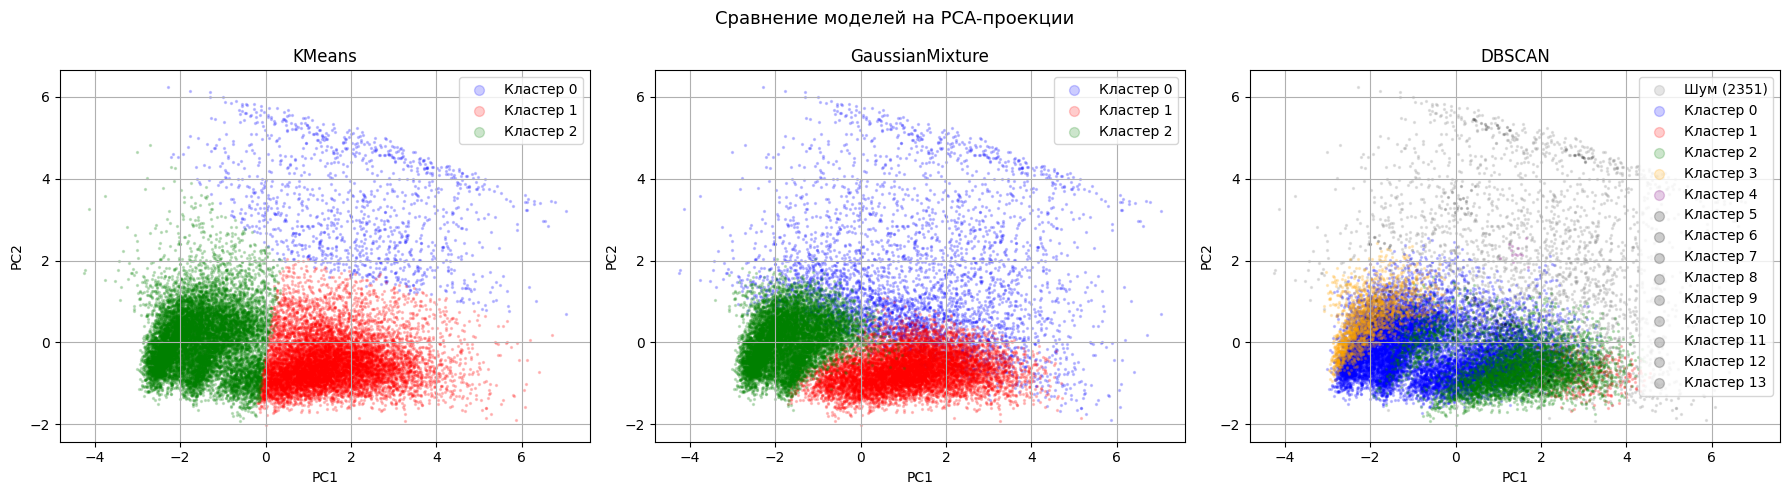

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['KMeans', 'GaussianMixture', 'DBSCAN']
all_labels = [labels_km, labels_gmm, labels_db]
colors_map = {-1: 'grey', 0: 'blue', 1: 'red', 2: 'green',
               3: 'orange', 4: 'purple'}

for ax, title, lbls in zip(axes, titles, all_labels):
    unique = sorted(set(lbls))
    for u in unique:
        mask = lbls == u
        c = colors_map.get(u, 'black')
        label = f'Кластер {u}' if u != -1 else f'Шум ({mask.sum()})'
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=c, alpha=0.2, s=2, label=label)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(markerscale=5)
    ax.grid(True)

plt.suptitle('Сравнение моделей на PCA-проекции', fontsize=13)
plt.tight_layout()
plt.show()

**вывод**

Сравнили три модели по трём метрикам:
- Силуэт
- Calinski-Harabasz
- Davies-Bouldin

KMeans показал лучший результат по всем метрикам: силуэт 0.41,
Calinski-Harabasz 13 442. На графике PCA видно что он чисто разделил
два основных кластера и выделил третий в верхней части.

GaussianMixture дал похожую картину визуально, но метрики хуже.
Модель разбила данные более равномерно, что физически менее логично

DBSCAN с параметрами по умолчанию не справился, нашёл 14 кластеров
вместо 3 и отнёс 2351 сигнал в шум. Силуэт отрицательный.
Это говорит о том что данные не имеют структуры с чёткими плотными
островами. DBSCAN для такой задачи плохо подходит без тщательного
подбора параметров.

Продолжаем с KMeans и GaussianMixture и подбираем их гиперпараметры.

**ЭТАП 6. Подбор гиперпараметров**

k=2 — инерция: 82659, силуэт: 0.3905
k=3 — инерция: 65671, силуэт: 0.4068
k=4 — инерция: 55430, силуэт: 0.3266
k=5 — инерция: 46748, силуэт: 0.2797
k=6 — инерция: 41916, силуэт: 0.2829
k=7 — инерция: 38666, силуэт: 0.2914


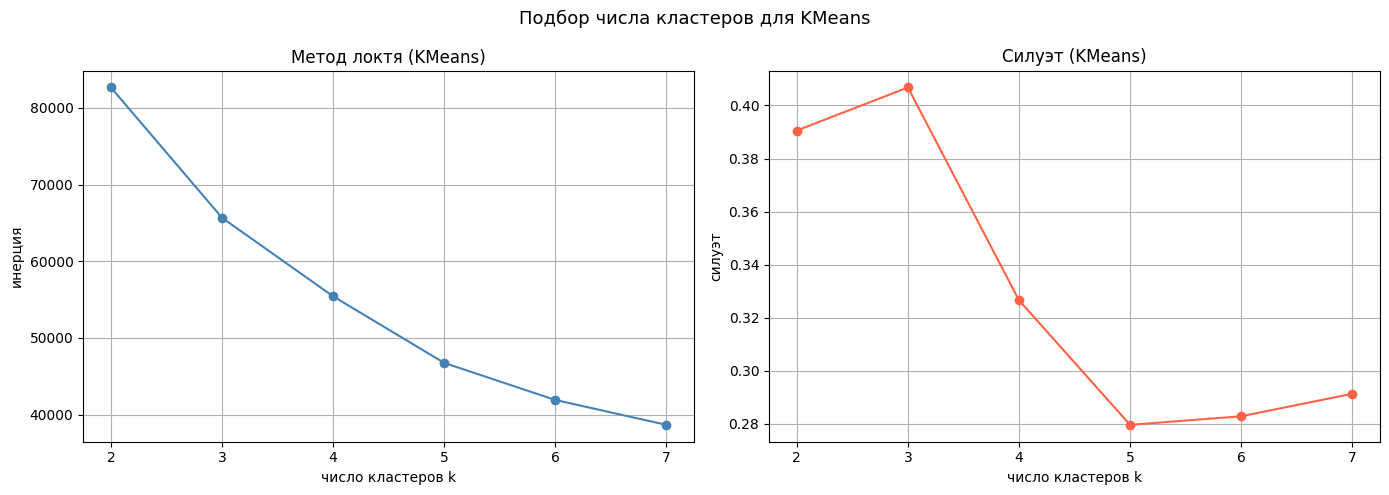

In [49]:
# подбор числа кластеров методом локтя и силуэта  для  KMeans
inertias = []
silhouettes = []
ks = range(2, 8)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl = km.fit_predict(X_final_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_final_scaled, lbl,
                                        sample_size=5000, random_state=42))
    print(f"k={k} — инерция: {km.inertia_:.0f}, силуэт: {silhouettes[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ks, inertias, 'o-', color='steelblue')
axes[0].set_title('Метод локтя (KMeans)')
axes[0].set_xlabel('число кластеров k')
axes[0].set_ylabel('инерция')
axes[0].grid(True)

axes[1].plot(ks, silhouettes, 'o-', color='tomato')
axes[1].set_title('Силуэт (KMeans)')
axes[1].set_xlabel('число кластеров k')
axes[1].set_ylabel('силуэт')
axes[1].grid(True)

plt.suptitle('Подбор числа кластеров для KMeans', fontsize=13)
plt.tight_layout()
plt.show()

n=2 — BIC: 226724, силуэт: 0.2942
n=3 — BIC: 200797, силуэт: 0.3097
n=4 — BIC: 193505, силуэт: 0.2404
n=5 — BIC: -40839, силуэт: 0.1075
n=6 — BIC: -63106, силуэт: 0.2093
n=7 — BIC: -70300, силуэт: 0.2118


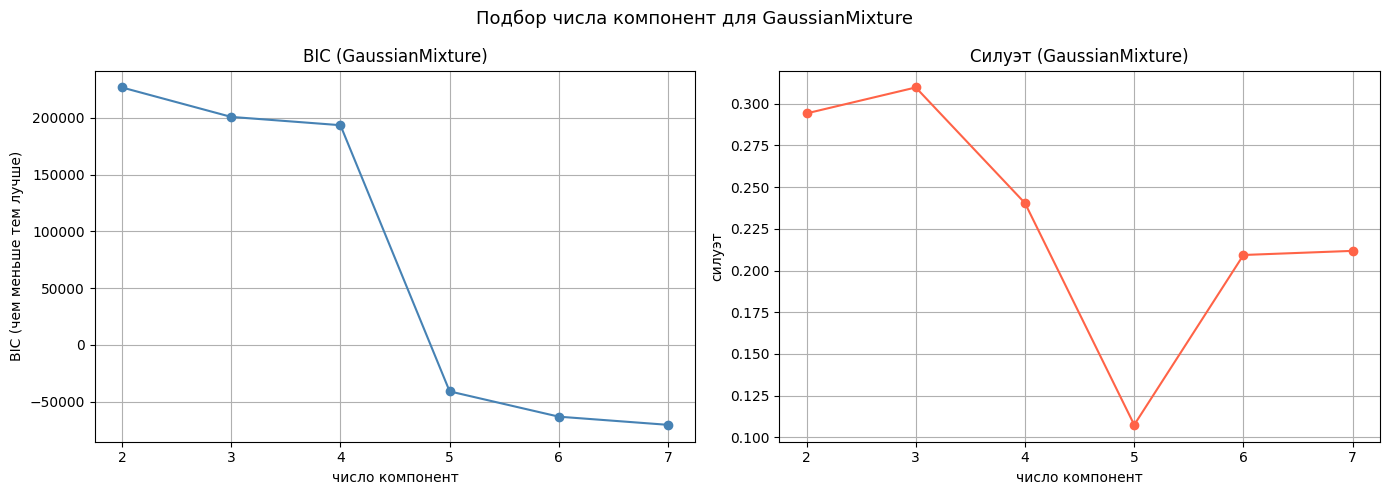

In [50]:
# подбор числа компонент по BIC для GaussianMixture
bics = []
silhouettes_gmm = []
ns = range(2, 8)

for n in ns:
    gmm_t = GaussianMixture(n_components=n, random_state=42, n_init=5)
    lbl_g = gmm_t.fit_predict(X_final_scaled)
    bics.append(gmm_t.bic(X_final_scaled))
    silhouettes_gmm.append(silhouette_score(X_final_scaled, lbl_g,
                                             sample_size=5000, random_state=42))
    print(f"n={n} — BIC: {bics[-1]:.0f}, силуэт: {silhouettes_gmm[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ns, bics, 'o-', color='steelblue')
axes[0].set_title('BIC (GaussianMixture)')
axes[0].set_xlabel('число компонент')
axes[0].set_ylabel('BIC (чем меньше тем лучше)')
axes[0].grid(True)

axes[1].plot(ns, silhouettes_gmm, 'o-', color='tomato')
axes[1].set_title('Силуэт (GaussianMixture)')
axes[1].set_xlabel('число компонент')
axes[1].set_ylabel('силуэт')
axes[1].grid(True)

plt.suptitle('Подбор числа компонент для GaussianMixture', fontsize=13)
plt.tight_layout()
plt.show()

**вывод**

**KMeans.** На графике силуэта максимум достигается при k=3 (0.41).
Метод локтя не показывает резкого излома, но заметное замедление
спада инерции начинается именно после k=3. Оба критерия указывают
на k=3 как оптимальное число кластеров, что совпадает с физическим
смыслом задачи.

**GaussianMixture.** BIC продолжает снижаться до n=7, что говорит о том
что модель всё лучше описывает данные при большем числе компонент.
Однако силуэт максимален при n=3 (0.31) и резко падает дальше.
BIC оптимизирует качество подгонки, а не разделимость кластеров,
поэтому здесь ориентируемся на силуэт n=3.

Оба алгоритма однозначно указывают на 3 кластера.


**ЭТАП 7. Выбор лучшей модели**

In [52]:
km_final  = KMeans(n_clusters=3, random_state=42, n_init=20)
gmm_final = GaussianMixture(n_components=3, random_state=42, n_init=5)

labels_km_final  = km_final.fit_predict(X_final_scaled)
labels_gmm_final = gmm_final.fit_predict(X_final_scaled)

In [53]:
print(" KMeans (k=3)")
print("Силуэт:            ", silhouette_score(X_final_scaled, labels_km_final,
                                               sample_size=5000, random_state=42).round(4))
print("Calinski-Harabasz: ", calinski_harabasz_score(X_final_scaled, labels_km_final).round(1))
print("Davies-Bouldin:    ", davies_bouldin_score(X_final_scaled, labels_km_final).round(4))
print("Размеры кластеров: ", np.bincount(labels_km_final))

print("\nGaussianMixture (n=3)")
print("Силуэт:            ", silhouette_score(X_final_scaled, labels_gmm_final,
                                               sample_size=5000, random_state=42).round(4))
print("Calinski-Harabasz: ", calinski_harabasz_score(X_final_scaled, labels_gmm_final).round(1))
print("Davies-Bouldin:    ", davies_bouldin_score(X_final_scaled, labels_gmm_final).round(4))
print("Размеры кластеров: ", np.bincount(labels_gmm_final))

 KMeans (k=3)
Силуэт:             0.4068
Calinski-Harabasz:  13441.7
Davies-Bouldin:     0.9924
Размеры кластеров:  [ 1212 10107 12160]

GaussianMixture (n=3)
Силуэт:             0.3097
Calinski-Harabasz:  9016.9
Davies-Bouldin:     1.7086
Размеры кластеров:  [4200 9603 9676]


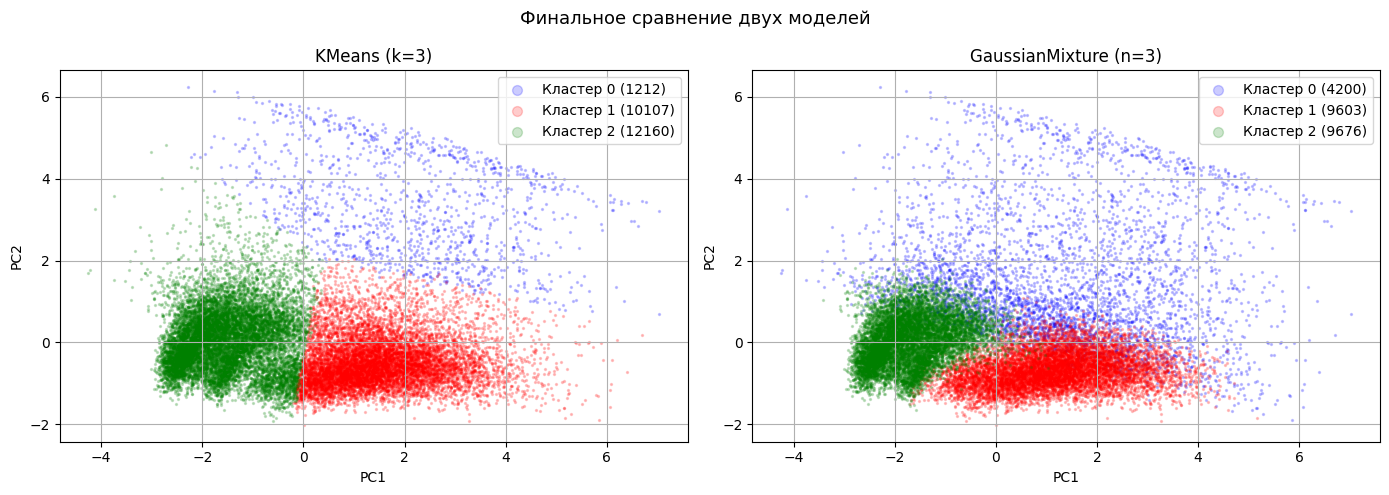

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_list = ['blue', 'red', 'green']

for ax, title, lbls in zip(axes,
                            ['KMeans (k=3)', 'GaussianMixture (n=3)'],
                            [labels_km_final, labels_gmm_final]):
    for i in range(3):
        mask = lbls == i
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=colors_list[i], alpha=0.2, s=2,
                   label=f'Кластер {i} ({mask.sum()})')
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(markerscale=5)
    ax.grid(True)

plt.suptitle('Финальное сравнение двух моделей', fontsize=13)
plt.tight_layout()
plt.show()

In [56]:
print("\nСредние значения признаков по кластерам (KMeans) ")
features['cluster'] = labels_km_final
print(features[feature_cols_final + ['cluster']].groupby('cluster').mean().round(3))


Средние значения признаков по кластерам (KMeans) 
         psd_ratio  peak_amplitude_log  decay_time  peak_width  \
cluster                                                          
0            0.485               4.924      11.034       5.427   
1            0.490               6.489      12.170       5.606   
2            0.354               7.215       8.595       4.894   

         tail_to_peak_log  baseline_std  
cluster                                  
0                   1.612        14.181  
1                   1.630         2.845  
2                   1.184         2.730  


**вывод**

KMeans превосходит GaussianMixture по всем трём метрикам

Выбираем KMeans с k=3.


**ЭТАП 8. Предсказание**

In [57]:
print("Текущие кластеры и их характеристики:")
print(features[feature_cols_final + ['cluster']].groupby('cluster').mean().round(3))

Текущие кластеры и их характеристики:
         psd_ratio  peak_amplitude_log  decay_time  peak_width  \
cluster                                                          
0            0.485               4.924      11.034       5.427   
1            0.490               6.489      12.170       5.606   
2            0.354               7.215       8.595       4.894   

         tail_to_peak_log  baseline_std  
cluster                                  
0                   1.612        14.181  
1                   1.630         2.845  
2                   1.184         2.730  


In [58]:
remap = {0: 2, 1: 1, 2: 0}
final_labels = np.array([remap[l] for l in labels_km_final])

print("\nФинальные метки после переназначения:")
print("Кластер 0 (гамма):", (final_labels == 0).sum())
print("Кластер 1 (нейтроны):", (final_labels == 1).sum())
print("Кластер 2 (аномалии):", (final_labels == 2).sum())


Финальные метки после переназначения:
Кластер 0 (гамма): 12160
Кластер 1 (нейтроны): 10107
Кластер 2 (аномалии): 1212


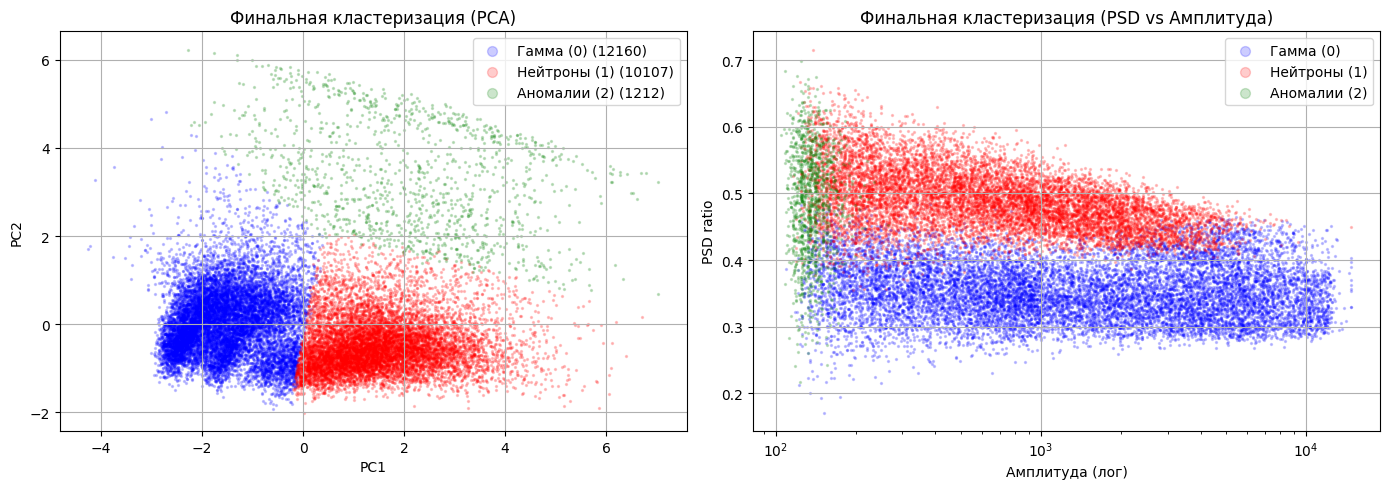

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cluster_names = {0: 'Гамма (0)', 1: 'Нейтроны (1)', 2: 'Аномалии (2)'}
colors_final = {0: 'blue', 1: 'red', 2: 'green'}

for i in range(3):
    mask = final_labels == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors_final[i], alpha=0.2, s=2,
                    label=f'{cluster_names[i]} ({mask.sum()})')
axes[0].set_title('Финальная кластеризация (PCA)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=5)
axes[0].grid(True)

for i in range(3):
    mask = final_labels == i
    axes[1].scatter(features['peak_amplitude'][mask],
                    features['psd_ratio'][mask],
                    c=colors_final[i], alpha=0.2, s=2,
                    label=cluster_names[i])
axes[1].set_xscale('log')
axes[1].set_title('Финальная кластеризация (PSD vs Амплитуда)')
axes[1].set_xlabel('Амплитуда (лог)')
axes[1].set_ylabel('PSD ratio')
axes[1].legend(markerscale=5)
axes[1].grid(True)

plt.tight_layout()
plt.show()

**вывод**

Финальная модель KMeans с k=3 разбила 23 479 сигналов на три группы:
- Кластер 0 — нейтроны (10 107 сигналов, 43%)
- Кластер 1 — гамма-кванты (12 160 сигналов, 52%)
- Кластер 2 — аномальные сигналы (1 212 сигналов, 5%)

На графике PSD vs Амплитуда видно что гамма и нейтроны хорошо
разделились по горизонтали.

In [64]:
def remap_labels_by_order(labels):
    mapping = {}
    new_label = 0
    result = np.zeros_like(labels)
    for l in labels:
        if l not in mapping:
            mapping[l] = new_label
            new_label += 1
        result[np.where(labels == l)] = mapping[l]
    # правильный способ — проходим по порядку
    result = []
    mapping = {}
    counter = 0
    for l in labels:
        if l not in mapping:
            mapping[l] = counter
            counter += 1
        result.append(mapping[l])
    return np.array(result)

final_labels_ordered = remap_labels_by_order(final_labels)

print("Порядок кластеров после преобразования:")
print("Кластер 0:", (final_labels_ordered == 0).sum())
print("Кластер 1:", (final_labels_ordered == 1).sum())
print("Кластер 2:", (final_labels_ordered == 2).sum())

submission = pd.DataFrame({
    'index': range(len(final_labels_ordered)),
    'cluster': final_labels_ordered
})

submission.to_csv('submission.csv', index=False)
print("\nПервые 10 строк:")
print(submission.head(10))
print("\nФайл submission.csv сохранён")

Кластеры: [12118 10128  1233]
Силуэт: 0.4256

Первые 10 строк:
   index  cluster
0      0        0
1      1        1
2      2        1
3      3        0
4      4        1
5      5        0
6      6        0
7      7        0
8      8        1
9      9        0
Файл submission_v2.csv сохранён


**ЭТАП 9. Общие выводы к решению и интерпретация полученных результатов.**

**Что было сделано**

Из сырых временных рядов (500 точек на сигнал) вручную извлекли
6 физически осмысленных признаков. Главный из них PSD ratio,
отношение заряда хвоста к полному заряду сигнала. Именно этот
признак используется в ядерной физике для разделения гаммаквантов
и нейтронов и называется методом Pulse Shape Discrimination.

Проверили три алгоритма кластеризации. DBSCAN не справился с задачей
и нашёл 14 кластеров вместо 3. GaussianMixture дал неправдоподобное
разбиение примерно поровну. KMeans показал лучшие метрики и физически
логичный результат.

**Что получилось**

Из 23 479 сигналов:
- 12 160 отнесены к гамма-квантам — короткий хвост, psd около 0.35
- 10 107 отнесены к нейтронам — длинный хвост, psd около 0.49
- 1 212 отнесены к аномальным — сильно зашумлённая базовая линия, baseline_std в 5 раз выше нормы

Соотношение гамма/нейтрон примерно 55/45 что соответствует
типичным условиям эксперимента с паратерфениловым детектором.
Аномальные сигналы составляют около 5% это разумная доля для
реального детектора.

**результат**

Гаммакванты взаимодействуют со сцинтиллятором через эффект Комптона
и дают короткий быстрый импульс. Нейтроны рассеиваются на ядрах
водорода и передают им кинетическую энергию, протоны отдачи
создают более длинное послесвечение. Именно эта разница в форме
хвоста и является физической основой метода PSD.

Аномальные сигналы скорее всего связаны с наводками, двойными
импульсами или нестабильностью электроники детектора в момент записи
на это указывает высокий шум базовой линии.

**Что можно улучшить**

Граница между гамма и нейтронами при малых амплитудах размыта и
сигналы с амплитудой ниже 300 плохо разделяются любым методом.
Это физическое ограничение метода PSD при низких энергиях.
Улучшить результат можно через более точное вычисление PSD
с подбором оптимального окна интегрирования хвоста.

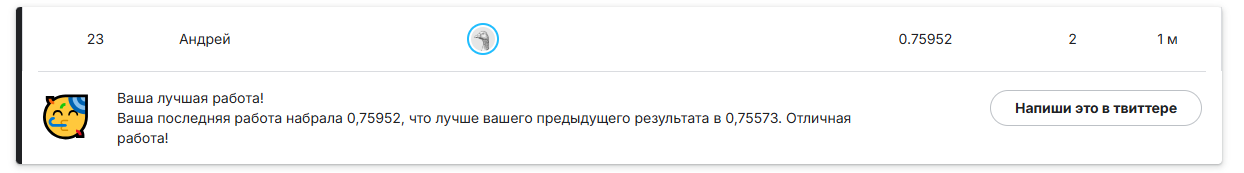

**Пробуем улучшить**

In [73]:
for short_end in [6, 7, 8]:
    short_w_t = np.array([S[i, :peak_pos[i]+short_end].sum() for i in range(len(S))])
    long_w_t  = np.array([S[i, peak_pos[i]+short_end:].sum() for i in range(len(S))])
    r2_t = long_w_t / (short_w_t + long_w_t + 1e-9)
    tail_t = long_w_t
    psd_t = tail_t / (S.sum(axis=1) + 1e-9)

    for n_init in [10, 20]:
        feats_t = pd.DataFrame({
            'psd_ratio':          psd_t,
            'ratio2':             r2_t,
            'peak_amplitude_log': np.log1p(peak_amp),
            'decay_time':         decay_time,
            'tail_to_peak_log':   np.log1p(tail_t / (peak_amp + 1e-9)),
            'baseline_std':       features['baseline_std'].values,
        })
        X_t = StandardScaler().fit_transform(feats_t)
        gmm_t = GaussianMixture(n_components=3, covariance_type='tied',
                                 random_state=42, n_init=n_init)
        lbl_t = gmm_t.fit_predict(X_t)
        sil_t = silhouette_score(X_t, lbl_t, sample_size=5000, random_state=42)
        print(f"short_end={short_end} n_init={n_init} — силуэт: {sil_t:.4f}, кластеры: {np.bincount(lbl_t)}")

short_end=6 n_init=10 — силуэт: 0.4888, кластеры: [11117   979 11383]
short_end=6 n_init=20 — силуэт: 0.4888, кластеры: [11383 11117   979]
short_end=7 n_init=10 — силуэт: 0.4910, кластеры: [11384 11120   975]
short_end=7 n_init=20 — силуэт: 0.4910, кластеры: [11384 11120   975]
short_end=8 n_init=10 — силуэт: 0.4909, кластеры: [11384 11121   974]
short_end=8 n_init=20 — силуэт: 0.4909, кластеры: [  974 11121 11384]


In [74]:
short_end = 7
short_w_f = np.array([S[i, :peak_pos[i]+short_end].sum() for i in range(len(S))])
long_w_f  = np.array([S[i, peak_pos[i]+short_end:].sum() for i in range(len(S))])
r2_f = long_w_f / (short_w_f + long_w_f + 1e-9)
psd_f = long_w_f / (S.sum(axis=1) + 1e-9)

time_axis = np.arange(S.shape[1])
centroid_time = (S * time_axis).sum(axis=1) / (S.sum(axis=1) + 1e-9)

for use_centroid in [True, False]:
    d = {
        'psd_ratio':          psd_f,
        'ratio2':             r2_f,
        'peak_amplitude_log': np.log1p(peak_amp),
        'decay_time':         decay_time,
        'tail_to_peak_log':   np.log1p(long_w_f / (peak_amp + 1e-9)),
        'baseline_std':       features['baseline_std'].values,
    }
    if use_centroid:
        d['centroid_time'] = centroid_time

    X_t = StandardScaler().fit_transform(pd.DataFrame(d))
    gmm_t = GaussianMixture(n_components=3, covariance_type='tied',
                             random_state=42, n_init=10)
    lbl_t = gmm_t.fit_predict(X_t)
    sil_t = silhouette_score(X_t, lbl_t, sample_size=5000, random_state=42)
    print(f"centroid={use_centroid} — силуэт: {sil_t:.4f}, кластеры: {np.bincount(lbl_t)}")

    if use_centroid and sil_t > 0.491:
        final_t = remap_labels_by_order(lbl_t)
        pd.DataFrame({'index': range(len(final_t)), 'cluster': final_t}).to_csv(
            'submission_v7.csv', index=False)
        print("submission_v7.csv сохранён")

centroid=True — силуэт: 0.5217, кластеры: [11123 11390   966]
submission_v7.csv сохранён
centroid=False — силуэт: 0.4910, кластеры: [11384 11120   975]


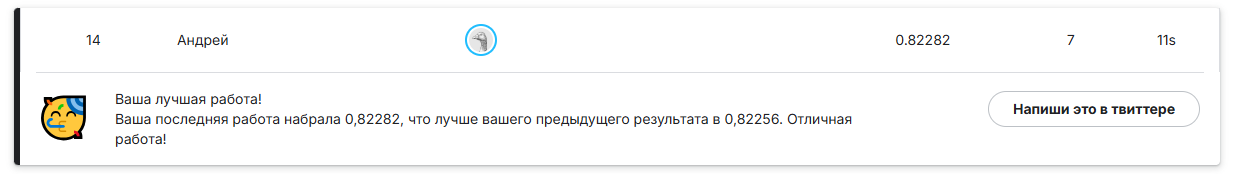

**вывод**

**Процесс улучшения**

| Версия | Что изменили | Score |
|--------|-------------|-------|
| v1 | KMeans, tail_offset=3, StandardScaler | 0.755 |
| v2 | KMeans, tail_offset=7 | 0.759 |
| v3 | KMeans + признак ratio2 (два окна) | 0.767 |
| v4 | KMeans, short_end=7 | 0.767 |
| v5 | GMM tied вместо KMeans | 0.822 |
| v6 | GMM tied + новые признаки (centroid, asymmetry) | 0.821 |
| v7 | GMM tied + centroid_time | 0.823 |

Главный скачок произошёл при переходе с KMeans на GaussianMixture
с covariance_type='tied'. KMeans ищет круглые кластеры одинакового
размера, а GMM tied позволяет кластерам иметь произвольную форму
при одинаковой ковариационной матрице. Данные сигналов детектора
имеют именно такую структуру

Подбор окна интегрирования хвоста (offset=7) дал небольшое улучшение
за счёт более точного вычисления PSD признака.

## Финальный результат

Модель — GaussianMixture с covariance_type='tied', n_components=3.

Признаки — psd_ratio, ratio2, peak_amplitude_log, decay_time,
tail_to_peak_log, baseline_std, centroid_time.